<a href="https://colab.research.google.com/github/ervatoker/IOT-Erva-Toker/blob/main/RealMLPandTabM_updated_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CONFIG

DRIVE_DATASET = "/content/drive/MyDrive/datasets/toniot_arnob_dataset"
DRIVE_OUT_DIR = "/content/drive/MyDrive/toniot_outputs"

LABEL_COL   = "type"
RANDOM_SEED = 42
TEST_SIZE   = 0.2
VAL_SIZE    = 0.1

# Training settings
N_EPOCHS_GRANDE = 50
N_EPOCHS_TABM      = 256
EARLY_STOPPING     = 20   # stop if no improvement for 20 epochs
BATCH_SIZE      = 512
DEVICE          = "cuda"

In [1]:
# INSTALL

!pip install -q pytabkit
!pip install -q tabm
!pip install -q scikit-learn pandas numpy matplotlib seaborn

print(" All packages installed restart runtime!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.0 MB/s eta 0:00:00
 All packages installed restart runtime!


In [3]:
# IMPORTS + DRIVE + GPU CHECK

import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix,
                             precision_score, recall_score,
                             roc_auc_score, cohen_kappa_score,
                             matthews_corrcoef, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F

from google.colab import drive
drive.mount("/content/drive")
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

# GPU check will crash if no GPU
if not torch.cuda.is_available():
    raise RuntimeError(
        "\n\n NO GPU DETECTED!\n"
        "→ Go to Runtime - Change runtime type\n"
        "→ Select T4 GPU\n"
        "→ Click Save\n"
        "→ Re-run from Cell 1\n"
    )

device = torch.device("cuda")
print(f" GPU confirmed : {torch.cuda.get_device_name(0)}")
print(f" VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f" Device        : {device}")

Mounted at /content/drive
 GPU confirmed : Tesla T4
 VRAM          : 15.6 GB
 Device        : cuda


In [4]:
# LOAD DATA

csv_files = glob.glob(os.path.join(DRIVE_DATASET, "**/*.csv"), recursive=True)
print(f"Found {len(csv_files)} CSV files")

dfs = []
for f in csv_files:
    try:
        dfs.append(pd.read_csv(f, low_memory=False))
    except Exception as e:
        print(f"  Skipped {f}: {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {len(df):,}  |  Columns: {df.shape[1]}")
print(f"\nLabel distribution:\n{df[LABEL_COL].value_counts()}")

Found 1 CSV files
Total rows: 211,043  |  Columns: 44

Label distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043
Name: count, dtype: int64


In [5]:
# PREPROCESS
# Drop label + non-feature columns
drop_cols = [LABEL_COL]
for col in ["ts", "src_ip", "dst_ip", "src_mac", "dst_mac"]:
    if col in df.columns:
        drop_cols.append(col)

X = df.drop(columns=drop_cols)
y_raw = df[LABEL_COL]

# Encode string labels to integers
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

# Keep numeric only + replace inf
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Features: {X.shape[1]}")

# Split first before any imputation or scaling
# 70 / 10 / 20 split
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED,
    stratify=y_tv)

print(f"\nTrain : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")

# Impute NaN using TRAIN median only
# This prevents data leakage
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)

# Scale using TRAIN statistics only
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s   = scaler.transform(X_val).astype(np.float32)
X_test_s  = scaler.transform(X_test).astype(np.float32)

n_features = X_train_s.shape[1]
print(f"\nFeatures after preprocessing : {n_features}")
print(" Preprocessing complete — no data leakage")

Classes (10): ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Features: 17

Train : 147,729
Val   : 21,105
Test  : 42,209

Features after preprocessing : 17
 Preprocessing complete — no data leakage


In [6]:
# EVALUATION HELPER

def evaluate(model_name, y_true, y_pred, label_names, out_dir):
    acc        = accuracy_score(y_true, y_pred)
    f1_macro   = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name} — Results")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weighted:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=label_names, zero_division=0)}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    path = os.path.join(out_dir, f"{model_name.lower().replace(' ','_')}_cm.png")
    plt.savefig(path, dpi=150); plt.show()
    print(f"Saved: {path}")

    return {"model": model_name, "accuracy": acc,
            "f1_macro": f1_macro, "f1_weighted": f1_weighted}

In [7]:
# RealMLP

from pytabkit import RealMLP_TD_Classifier

realmlp_model = RealMLP_TD_Classifier(
    random_state=RANDOM_SEED,
    verbosity=1,          # print epoch progress
    device='cuda' if torch.cuda.is_available() else 'cpu',
)

print("Training RealMLP...")
realmlp_model.fit(
    X_train_s, y_train,   # training data
    X_val_s,   y_val      # validation data for early stopping
)
print("RealMLP training complete.")

Training RealMLP...
Columns classified as continuous: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Columns classified as categorical: []


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=256` reached.


RealMLP training complete.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cud

RealMLP probability scores available.

  RealMLP — Results
  Accuracy      : 0.9875
  F1 (macro)    : 0.9593
  F1 (weighted) : 0.9875

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00      4000
        ddos       0.98      0.98      0.98      4000
         dos       0.99      0.98      0.98      4000
   injection       0.97      0.96      0.97      4000
        mitm       0.67      0.75      0.71       209
      normal       1.00      1.00      1.00     10000
    password       0.99      0.99      0.99      4000
  ransomware       1.00      1.00      1.00      4000
    scanning       0.98      0.99      0.99      4000
         xss       0.97      0.98      0.98      4000

    accuracy                           0.99     42209
   macro avg       0.96      0.96      0.96     42209
weighted avg       0.99      0.99      0.99     42209



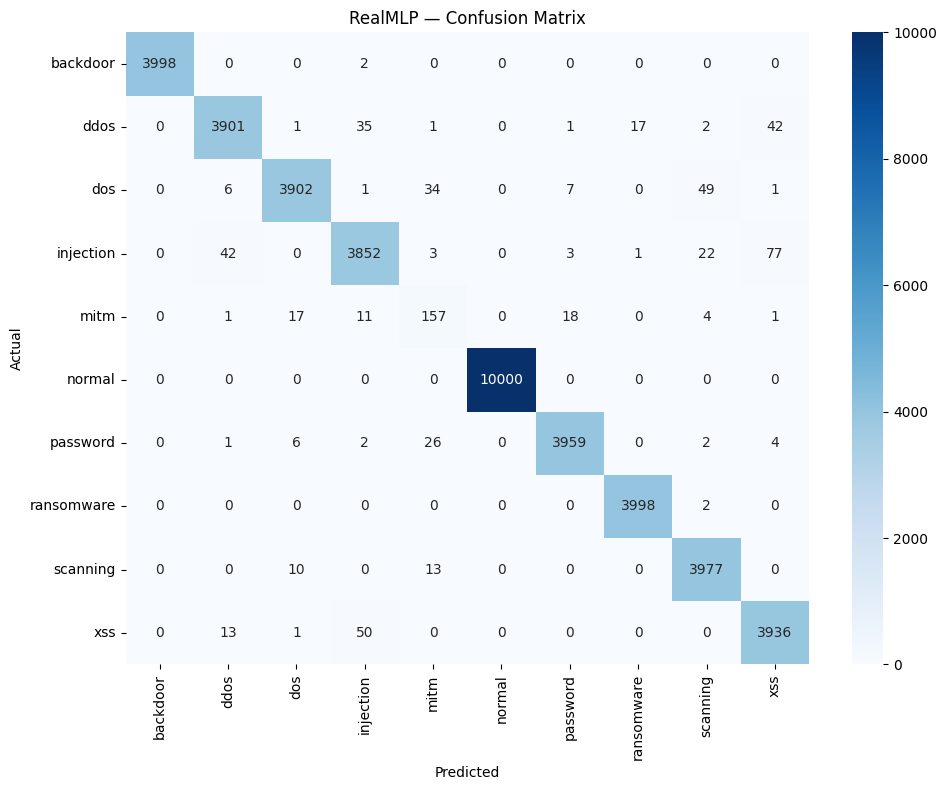

Saved: /content/drive/MyDrive/toniot_outputs/realmlp_cm.png


In [8]:
# RealMLP TEST EVALUATION

realmlp_preds = realmlp_model.predict(X_test_s)

# Try to get probabilities for ROC-AUC
realmlp_proba = None
try:
    realmlp_proba = realmlp_model.predict_proba(X_test_s)
    print("RealMLP probability scores available.")
except:
    print("Note: RealMLP predict_proba not available — ROC-AUC will be skipped.")

realmlp_results = evaluate(
    "RealMLP", y_test, realmlp_preds,
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR
)

  TABLE 1: RealMLP — Overall Evaluation Metrics
           Metric  Score
         Accuracy 0.9875
Precision (macro) 0.9558
   Recall (macro) 0.9632
       F1 (macro) 0.9593
    F1 (weighted) 0.9875
              MCC 0.9856
    Cohen's Kappa 0.9856
  ROC-AUC (macro) 0.9994



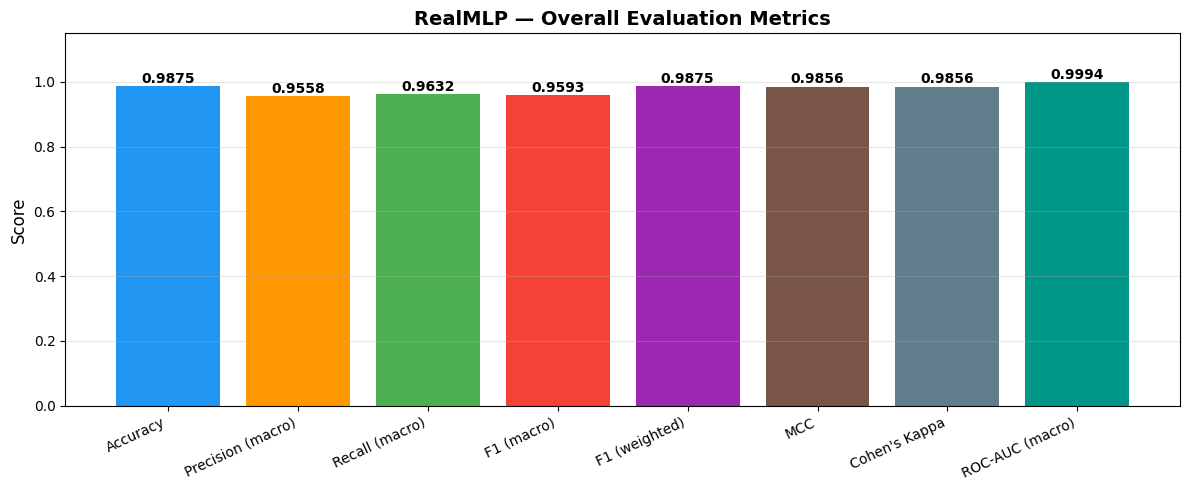

  TABLE 2: RealMLP — Per-Class Precision / Recall / F1
     Class  Precision  Recall  F1-Score  Support
  backdoor     1.0000  0.9995    0.9997     4000
      ddos     0.9841  0.9752    0.9797     4000
       dos     0.9911  0.9755    0.9832     4000
 injection     0.9744  0.9630    0.9687     4000
      mitm     0.6709  0.7512    0.7088      209
    normal     1.0000  1.0000    1.0000    10000
  password     0.9927  0.9898    0.9912     4000
ransomware     0.9955  0.9995    0.9975     4000
  scanning     0.9800  0.9942    0.9871     4000
       xss     0.9692  0.9840    0.9766     4000



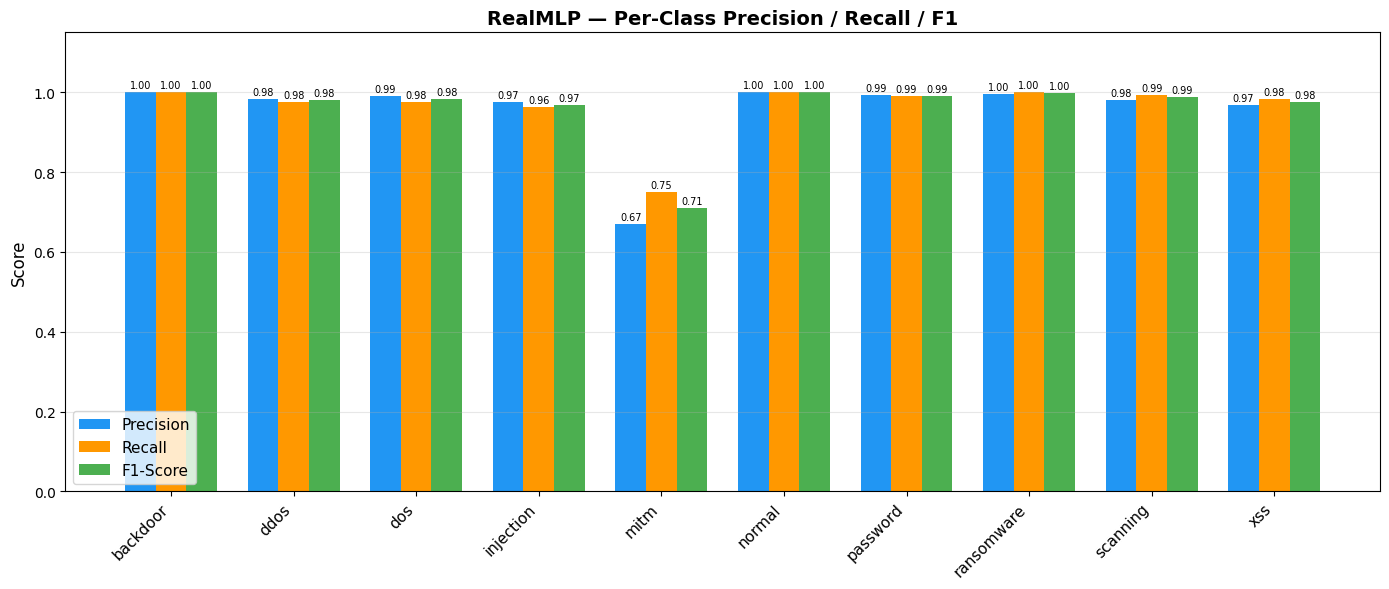

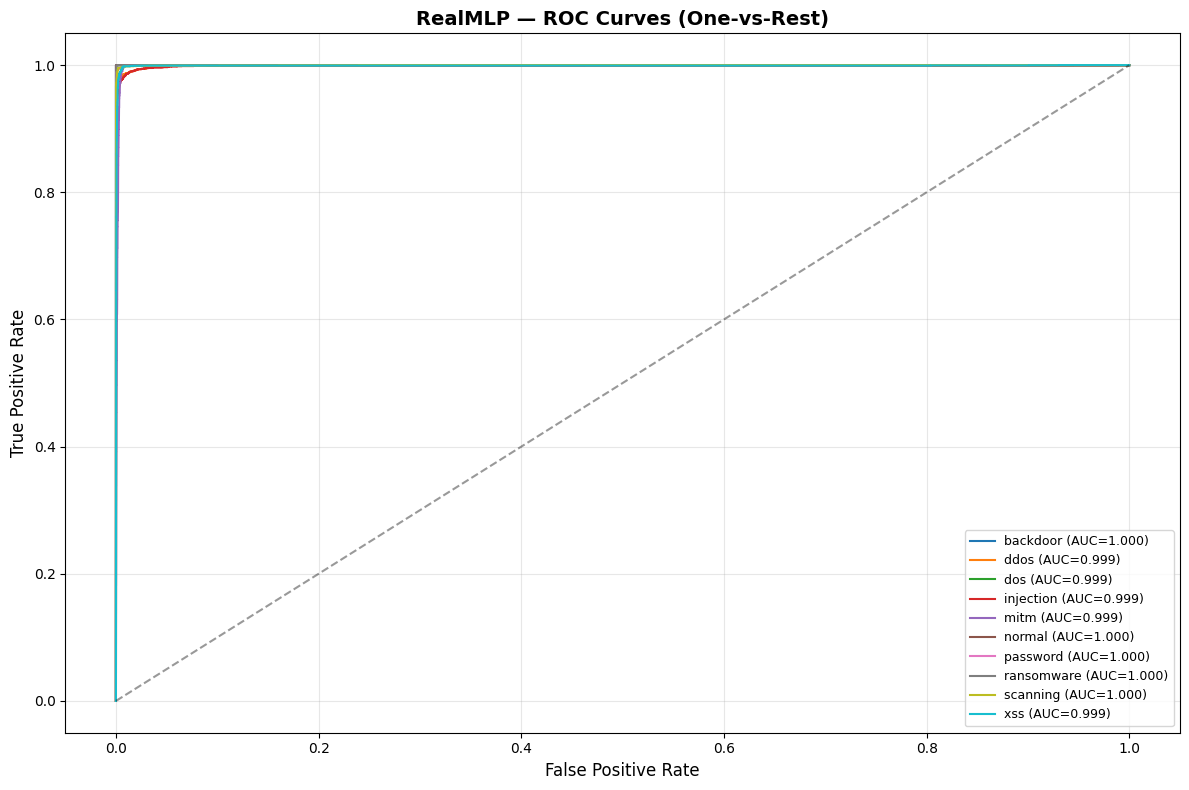

  TABLE 3: RealMLP — Per-Class ROC-AUC
     Class  ROC-AUC
  backdoor   1.0000
      ddos   0.9987
       dos   0.9994
 injection   0.9986
      mitm   0.9989
    normal   1.0000
  password   0.9999
ransomware   1.0000
  scanning   0.9998
       xss   0.9989

  Macro-average ROC-AUC: 0.9994

  TABLE 4: RealMLP — MCC & Cohen's Kappa
  MCC          : 0.9856 (Excellent)
  Cohen's Kappa: 0.9856 (Almost Perfect)


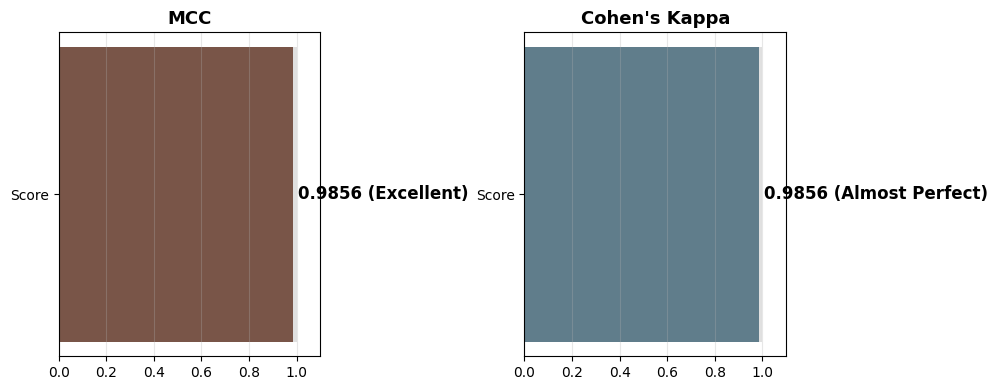

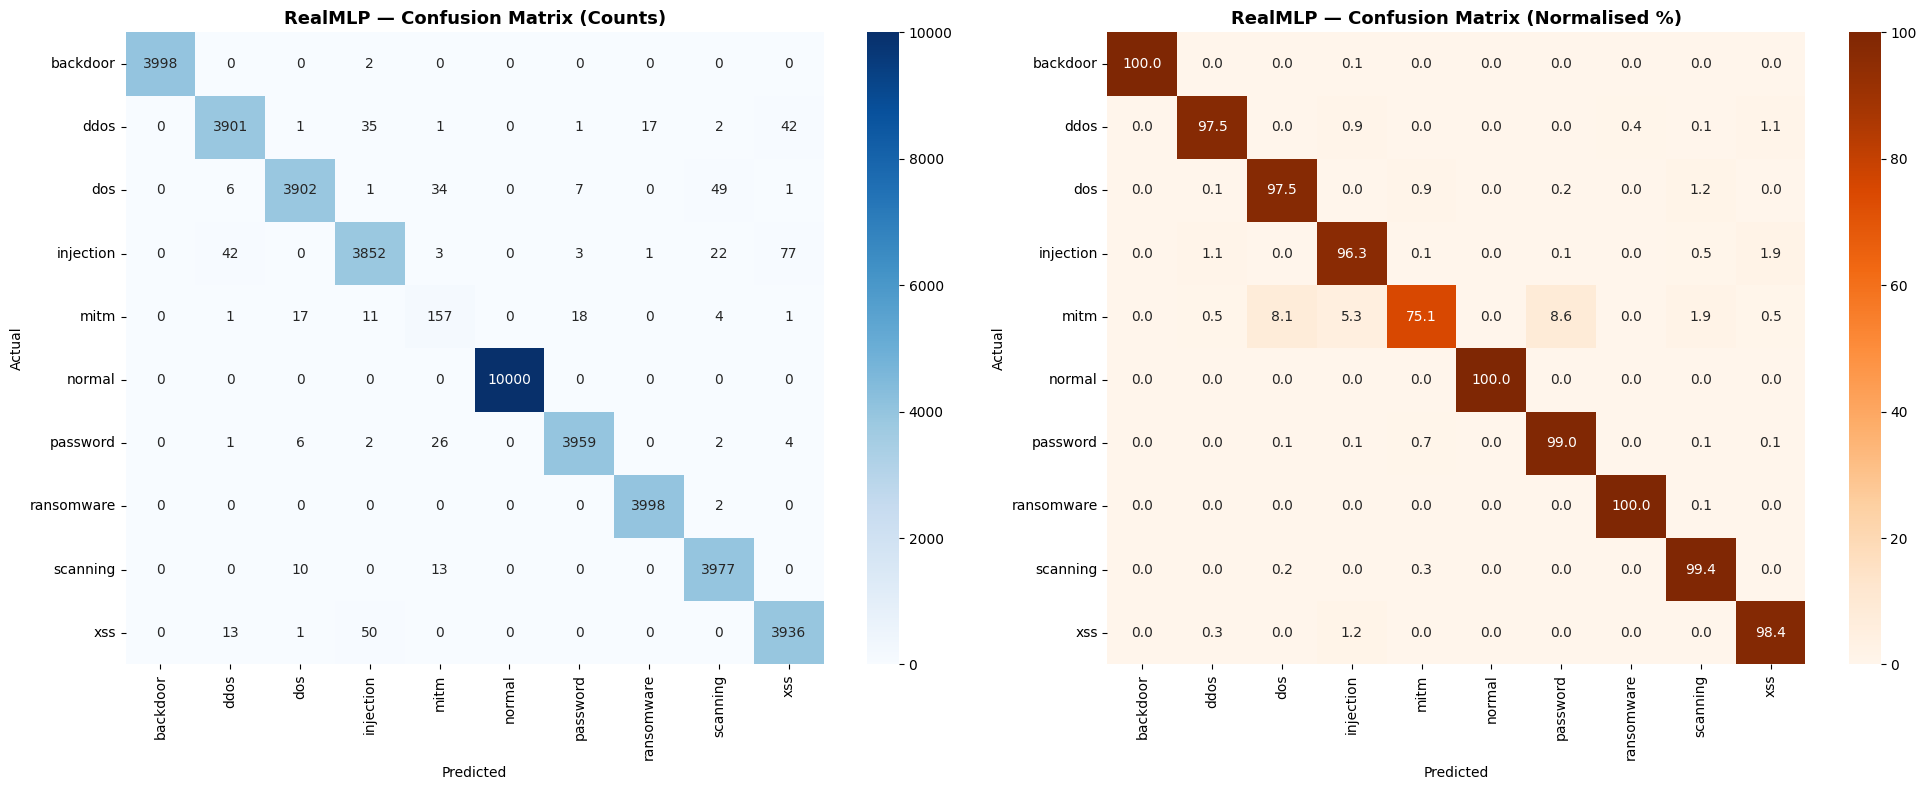


RealMLP visualisations saved to: /content/drive/MyDrive/toniot_outputs


In [9]:
# RealMLP — METRICS WITH TABLES & VISUALISATIONS

y_true = y_test
y_pred = realmlp_preds
y_prob = realmlp_proba
label_names = list(le.classes_)

acc         = accuracy_score(y_true, y_pred)
prec_macro  = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro   = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro    = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
mcc         = matthews_corrcoef(y_true, y_pred)
kappa       = cohen_kappa_score(y_true, y_pred)

roc_auc = None
if y_prob is not None:
    try:
        roc_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except:
        pass

# Store for later comparison
realmlp_metrics = dict(acc=acc, prec_macro=prec_macro, rec_macro=rec_macro,
    f1_macro=f1_macro, f1_weighted=f1_weighted, mcc=mcc, kappa=kappa, roc_auc=roc_auc)

macro_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)",
               "F1 (macro)", "F1 (weighted)", "MCC", "Cohen's Kappa",
               "ROC-AUC (macro)"],
    "Score": [acc, prec_macro, rec_macro, f1_macro, f1_weighted,
              mcc, kappa, roc_auc if roc_auc else float('nan')]
})
macro_df["Score"] = macro_df["Score"].round(4)

print("=" * 60)
print("  TABLE 1: RealMLP — Overall Evaluation Metrics")
print("=" * 60)
print(macro_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2196F3", "#FF9800", "#4CAF50", "#F44336", "#9C27B0", "#795548", "#607D8B", "#009688"]
valid = macro_df.dropna()
bars = ax.bar(valid["Metric"], valid["Score"], color=colors[:len(valid)])
for bar, val in zip(bars, valid["Score"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=12)
ax.set_title("RealMLP — Overall Evaluation Metrics", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.xticks(rotation=25, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "realmlp_macro_metrics.png"), dpi=150); plt.show()

# Per-class P/R/F1
prec_per = precision_score(y_true, y_pred, average=None, zero_division=0)
rec_per  = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per   = f1_score(y_true, y_pred, average=None, zero_division=0)

perclass_df = pd.DataFrame({
    "Class": label_names, "Precision": np.round(prec_per, 4),
    "Recall": np.round(rec_per, 4), "F1-Score": np.round(f1_per, 4),
    "Support": [np.sum(y_true == c) for c in range(num_classes)]
})
print("=" * 60)
print("  TABLE 2: RealMLP — Per-Class Precision / Recall / F1")
print("=" * 60)
print(perclass_df.to_string(index=False)); print()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(label_names)); w = 0.25
b1 = ax.bar(x - w, prec_per, w, label="Precision", color="#2196F3")
b2 = ax.bar(x,     rec_per,  w, label="Recall",    color="#FF9800")
b3 = ax.bar(x + w, f1_per,   w, label="F1-Score",  color="#4CAF50")
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01: ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(label_names, rotation=45, ha="right", fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=12)
ax.set_title("RealMLP — Per-Class Precision / Recall / F1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "realmlp_perclass_prf.png"), dpi=150); plt.show()

# ROC curves
if y_prob is not None:
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    auc_per_class = []
    fig, ax = plt.subplots(figsize=(12, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        class_auc = auc(fpr, tpr)
        auc_per_class.append(class_auc)
        ax.plot(fpr, tpr, label=f"{label_names[i]} (AUC={class_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_xlabel("False Positive Rate", fontsize=12); ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title("RealMLP — ROC Curves (One-vs-Rest)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_OUT_DIR, "realmlp_roc_curves.png"), dpi=150); plt.show()
    roc_df = pd.DataFrame({"Class": label_names, "ROC-AUC": np.round(auc_per_class, 4)})
    print("=" * 60)
    print("  TABLE 3: RealMLP — Per-Class ROC-AUC")
    print("=" * 60)
    print(roc_df.to_string(index=False))
    if roc_auc: print(f"\n  Macro-average ROC-AUC: {roc_auc:.4f}")
else:
    print("\nROC-AUC skipped (predict_proba not available).")

# MCC & Kappa
def interpret_mcc(v):
    if v >= 0.9: return "Excellent"
    if v >= 0.7: return "Strong"
    if v >= 0.5: return "Moderate"
    if v >= 0.3: return "Weak"
    return "Poor"
def interpret_kappa(v):
    if v >= 0.81: return "Almost Perfect"
    if v >= 0.61: return "Substantial"
    if v >= 0.41: return "Moderate"
    if v >= 0.21: return "Fair"
    return "Slight/Poor"

print(); print("=" * 60)
print("  TABLE 4: RealMLP — MCC & Cohen's Kappa")
print("=" * 60)
print(f"  MCC          : {mcc:.4f} ({interpret_mcc(mcc)})")
print(f"  Cohen's Kappa: {kappa:.4f} ({interpret_kappa(kappa)})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mn, val, interp, col in [
    (axes[0], "MCC", mcc, interpret_mcc(mcc), "#795548"),
    (axes[1], "Cohen's Kappa", kappa, interpret_kappa(kappa), "#607D8B")]:
    ax.barh(["Score"], [val], color=col, height=0.4)
    ax.barh(["Score"], [1.0], color="#E0E0E0", height=0.4, zorder=0)
    ax.set_xlim(0, 1.1)
    ax.text(val + 0.02, 0, f"{val:.4f} ({interp})", va="center", fontsize=12, fontweight="bold")
    ax.set_title(mn, fontsize=13, fontweight="bold"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "realmlp_mcc_kappa.png"), dpi=150); plt.show()

# Dual confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title("RealMLP — Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Oranges", xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title("RealMLP — Confusion Matrix (Normalised %)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "realmlp_cm_dual.png"), dpi=150); plt.show()

print("\nRealMLP visualisations saved to:", DRIVE_OUT_DIR)

In [10]:

# TabM
from tabm import TabM

X_tr = torch.tensor(X_train_s, dtype=torch.float32)
X_v  = torch.tensor(X_val_s,   dtype=torch.float32)
X_te = torch.tensor(X_test_s,  dtype=torch.float32)
y_tr = torch.tensor(y_train,   dtype=torch.long)
y_v  = torch.tensor(y_val,     dtype=torch.long)
y_te = torch.tensor(y_test,    dtype=torch.long)

train_dl = DataLoader(TensorDataset(X_tr, y_tr),
                      batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(TensorDataset(X_v,  y_v),
                      batch_size=BATCH_SIZE, shuffle=False)
test_dl  = DataLoader(TensorDataset(X_te, y_te),
                      batch_size=BATCH_SIZE, shuffle=False)

tabm_model = TabM.make(
    n_num_features=n_features,
    cat_cardinalities=[],
    d_out=num_classes,
).to(device)

optimizer = torch.optim.AdamW(
    tabm_model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

print(f"TabM params : {sum(p.numel() for p in tabm_model.parameters()):,}")
print(f"Device      : {device}")
print(f"Max epochs  : {N_EPOCHS_TABM}")
print(f"Early stop  : {EARLY_STOPPING} epochs patience")
print("Training TabM...")

best_val_f1       = 0
best_state        = None
tabm_history      = []
no_improve_count  = 0   # early stopping counter

for epoch in range(1, N_EPOCHS_TABM + 1):
    #  Train
    tabm_model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(tabm_model(xb).mean(dim=1), yb)
        loss.backward()
        optimizer.step()

    #  Validate
    tabm_model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for xb, yb in val_dl:
            p = tabm_model(xb.to(device)).mean(dim=1)\
                          .argmax(dim=-1).cpu().numpy()
            preds_all.extend(p)
            true_all.extend(yb.numpy())

    val_f1  = f1_score(true_all, preds_all,
                       average="macro", zero_division=0)
    val_acc = accuracy_score(true_all, preds_all)
    tabm_history.append({"epoch": epoch,
                         "val_f1": val_f1, "val_acc": val_acc})

    print(f"  Epoch {epoch:03d}/{N_EPOCHS_TABM} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f} | "
          f"No improve: {no_improve_count}/{EARLY_STOPPING}")

    # Save best / early stopping
    if val_f1 > best_val_f1:
        best_val_f1      = val_f1
        best_state       = {k: v.cpu()
                            for k, v in tabm_model.state_dict().items()}
        no_improve_count = 0
        print(f"   New best F1: {best_val_f1:.4f} — model saved")
    else:
        no_improve_count += 1
        if no_improve_count >= EARLY_STOPPING:
            print(f"\n⏹ Early stopping at epoch {epoch} "
                  f"— no improvement for {EARLY_STOPPING} epochs")
            break

print(f"\nBest Val F1 (TabM): {best_val_f1:.4f} ")

TabM params : 828,768
Device      : cuda
Max epochs  : 256
Early stop  : 20 epochs patience
Training TabM...
  Epoch 001/256 | Val Acc: 0.7968 | Val F1: 0.6947 | No improve: 0/20
   New best F1: 0.6947 — model saved
  Epoch 002/256 | Val Acc: 0.8281 | Val F1: 0.7384 | No improve: 0/20
   New best F1: 0.7384 — model saved
  Epoch 003/256 | Val Acc: 0.8679 | Val F1: 0.7696 | No improve: 0/20
   New best F1: 0.7696 — model saved
  Epoch 004/256 | Val Acc: 0.8816 | Val F1: 0.7960 | No improve: 0/20
   New best F1: 0.7960 — model saved
  Epoch 005/256 | Val Acc: 0.8982 | Val F1: 0.8204 | No improve: 0/20
   New best F1: 0.8204 — model saved
  Epoch 006/256 | Val Acc: 0.9046 | Val F1: 0.8225 | No improve: 0/20
   New best F1: 0.8225 — model saved
  Epoch 007/256 | Val Acc: 0.9277 | Val F1: 0.8539 | No improve: 0/20
   New best F1: 0.8539 — model saved
  Epoch 008/256 | Val Acc: 0.9409 | Val F1: 0.8696 | No improve: 0/20
   New best F1: 0.8696 — model saved
  Epoch 009/256 | Val Acc: 0.9421 |


  TabM — Results
  Accuracy      : 0.9793
  F1 (macro)    : 0.9453
  F1 (weighted) : 0.9793

              precision    recall  f1-score   support

    backdoor       0.99      1.00      1.00      4000
        ddos       0.97      0.96      0.97      4000
         dos       0.99      0.97      0.98      4000
   injection       0.95      0.95      0.95      4000
        mitm       0.68      0.63      0.65       209
      normal       1.00      1.00      1.00     10000
    password       0.99      0.99      0.99      4000
  ransomware       0.99      1.00      1.00      4000
    scanning       0.98      0.98      0.98      4000
         xss       0.94      0.96      0.95      4000

    accuracy                           0.98     42209
   macro avg       0.95      0.94      0.95     42209
weighted avg       0.98      0.98      0.98     42209



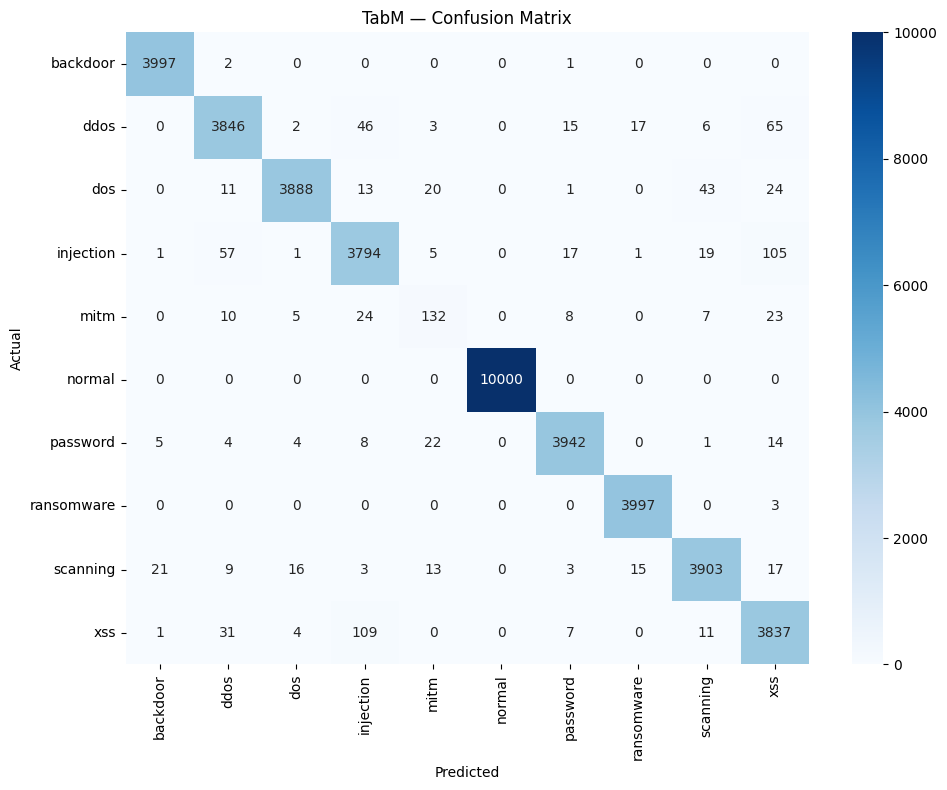

Saved: /content/drive/MyDrive/toniot_outputs/tabm_cm.png


In [11]:
# TabM TEST EVALUATION

tabm_model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
tabm_model.eval()

all_preds, all_true, all_proba = [], [], []
with torch.no_grad():
    for xb, yb in test_dl:
        logits = tabm_model(xb.to(device)).mean(dim=1)
        proba  = F.softmax(logits, dim=-1).cpu().numpy()
        preds  = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())
        all_proba.append(proba)

tabm_preds = np.array(all_preds)
tabm_proba = np.concatenate(all_proba, axis=0)

tabm_results = evaluate(
    "TabM", all_true, tabm_preds,
    label_names=list(le.classes_),
    out_dir=DRIVE_OUT_DIR
)

  TABLE 1: TabM — Overall Evaluation Metrics
           Metric  Score
         Accuracy 0.9793
Precision (macro) 0.9475
   Recall (macro) 0.9433
       F1 (macro) 0.9453
    F1 (weighted) 0.9793
              MCC 0.9763
    Cohen's Kappa 0.9763
  ROC-AUC (macro) 0.9980



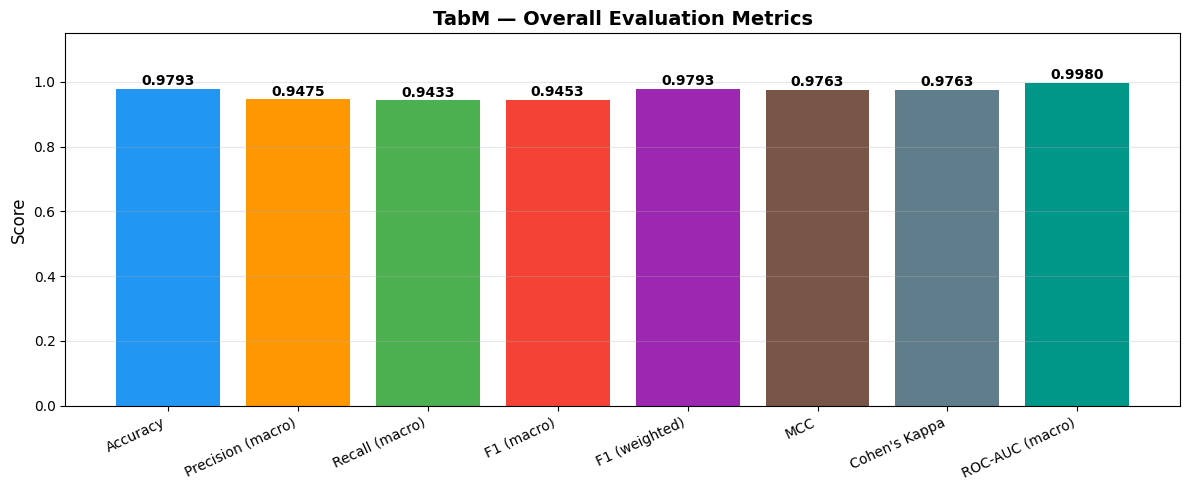

  TABLE 2: TabM — Per-Class Precision / Recall / F1
     Class  Precision  Recall  F1-Score  Support
  backdoor     0.9930  0.9992    0.9961     4000
      ddos     0.9688  0.9615    0.9651     4000
       dos     0.9918  0.9720    0.9818     4000
 injection     0.9492  0.9485    0.9489     4000
      mitm     0.6769  0.6316    0.6535      209
    normal     1.0000  1.0000    1.0000    10000
  password     0.9870  0.9855    0.9862     4000
ransomware     0.9918  0.9992    0.9955     4000
  scanning     0.9782  0.9758    0.9770     4000
       xss     0.9386  0.9592    0.9488     4000



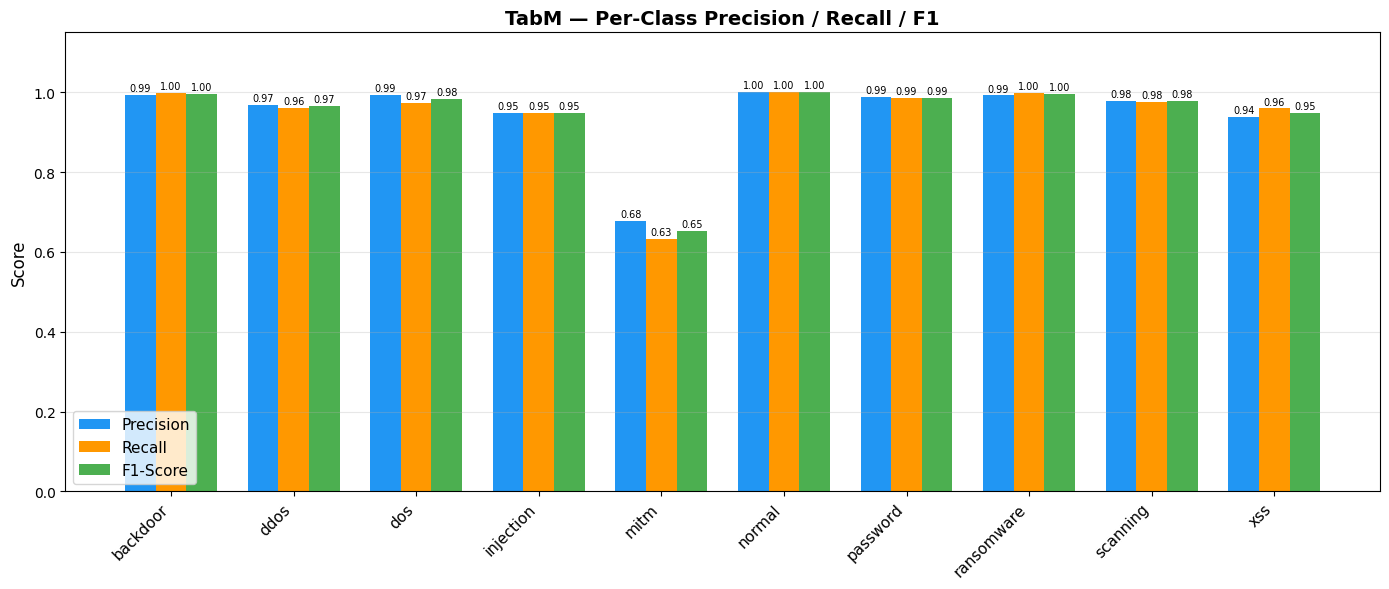

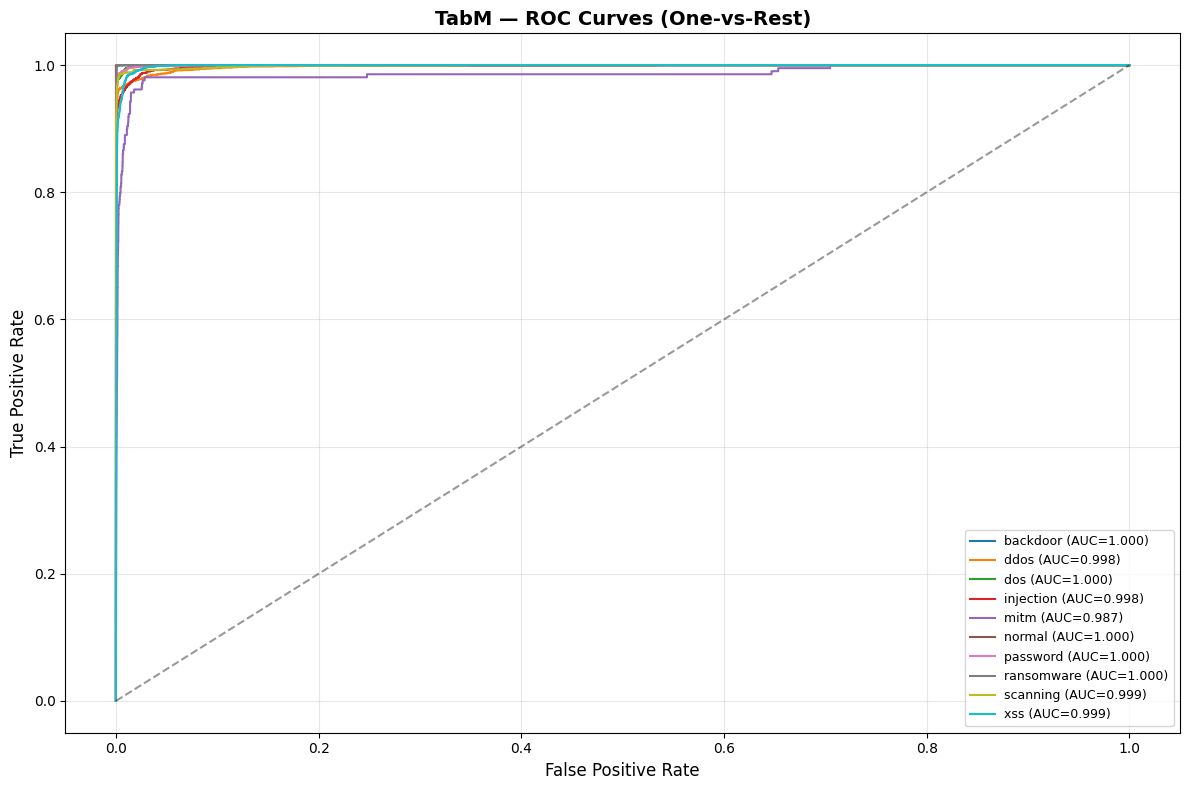

  TABLE 3: TabM — Per-Class ROC-AUC
     Class  ROC-AUC
  backdoor   0.9999
      ddos   0.9981
       dos   0.9997
 injection   0.9983
      mitm   0.9865
    normal   1.0000
  password   0.9996
ransomware   0.9999
  scanning   0.9989
       xss   0.9988

  Macro-average ROC-AUC: 0.9980

  TABLE 4: TabM — MCC & Cohen's Kappa
  MCC          : 0.9763 (Excellent)
  Cohen's Kappa: 0.9763 (Almost Perfect)


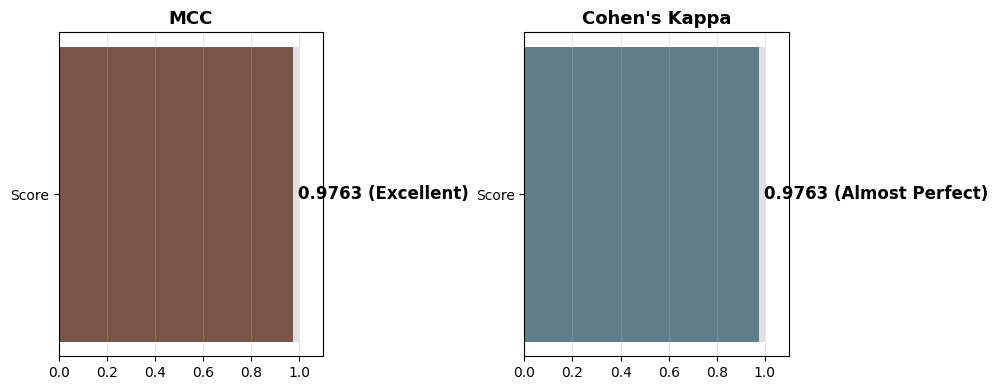

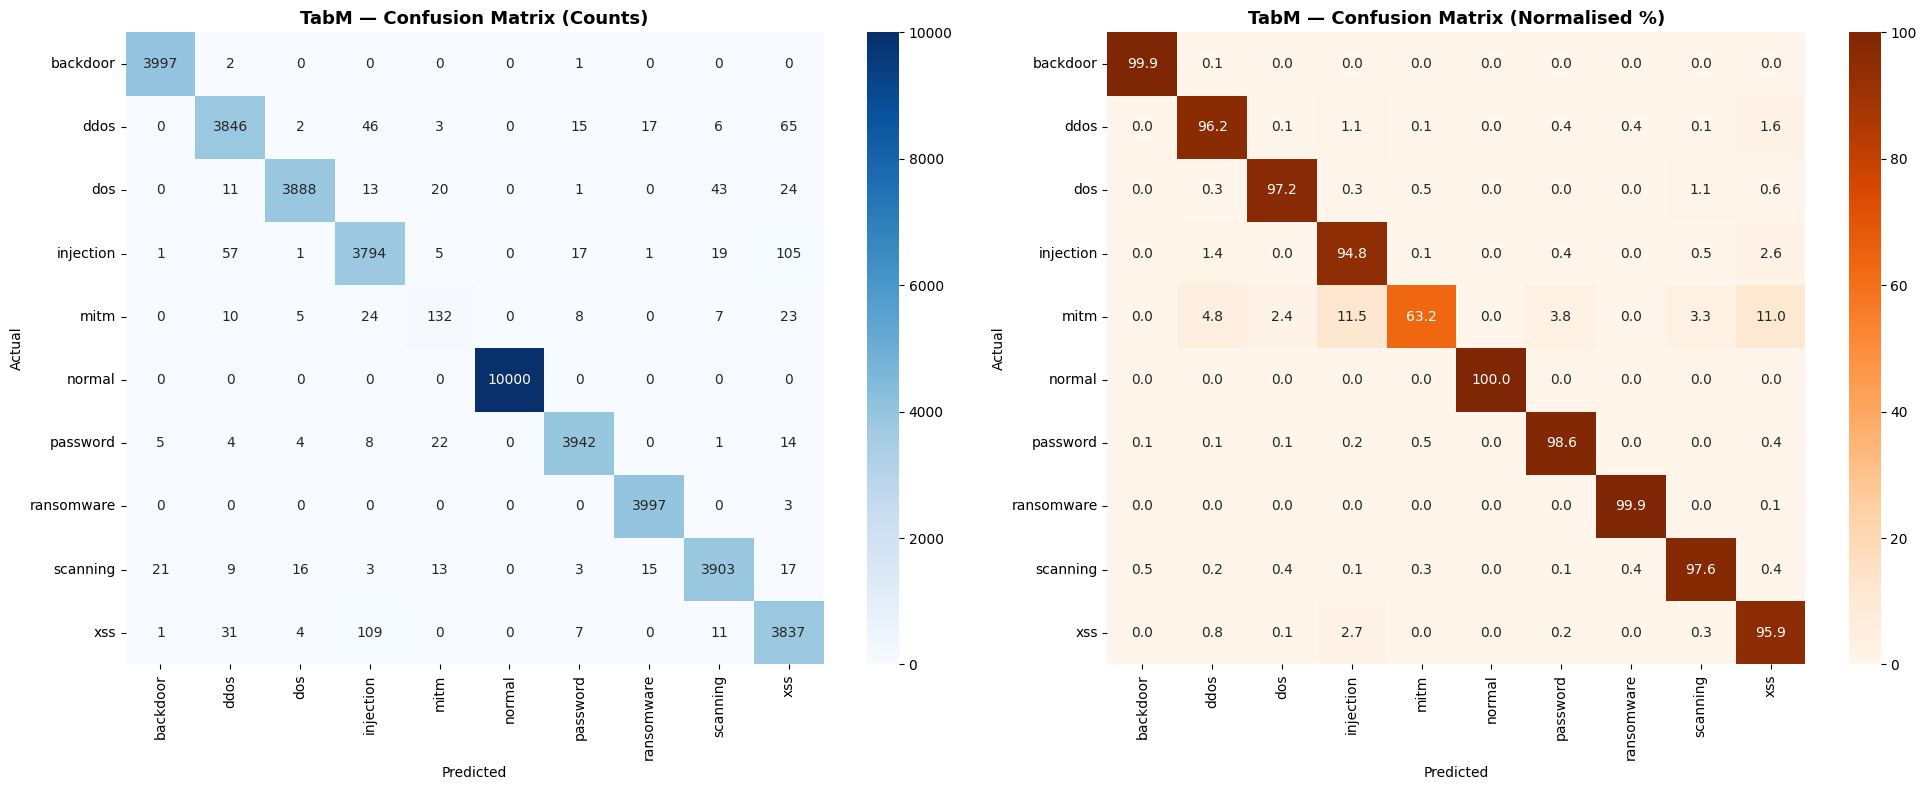


TabM visualisations saved to: /content/drive/MyDrive/toniot_outputs


In [12]:
# TabM — TABLES & VISUALISATIONS

y_true = y_test
y_pred = tabm_preds
y_prob = tabm_proba
label_names = list(le.classes_)

acc         = accuracy_score(y_true, y_pred)
prec_macro  = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro   = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro    = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
mcc         = matthews_corrcoef(y_true, y_pred)
kappa       = cohen_kappa_score(y_true, y_pred)

roc_auc = None
if y_prob is not None:
    try:
        roc_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except:
        pass

# Store for later comparison
tabm_metrics = dict(acc=acc, prec_macro=prec_macro, rec_macro=rec_macro,
    f1_macro=f1_macro, f1_weighted=f1_weighted, mcc=mcc, kappa=kappa, roc_auc=roc_auc)

macro_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)",
               "F1 (macro)", "F1 (weighted)", "MCC", "Cohen's Kappa",
               "ROC-AUC (macro)"],
    "Score": [acc, prec_macro, rec_macro, f1_macro, f1_weighted,
              mcc, kappa, roc_auc if roc_auc else float('nan')]
})
macro_df["Score"] = macro_df["Score"].round(4)

print("=" * 60)
print("  TABLE 1: TabM — Overall Evaluation Metrics")
print("=" * 60)
print(macro_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#2196F3", "#FF9800", "#4CAF50", "#F44336", "#9C27B0", "#795548", "#607D8B", "#009688"]
valid = macro_df.dropna()
bars = ax.bar(valid["Metric"], valid["Score"], color=colors[:len(valid)])
for bar, val in zip(bars, valid["Score"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=12)
ax.set_title("TabM — Overall Evaluation Metrics", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3); plt.xticks(rotation=25, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "tabm_macro_metrics.png"), dpi=150); plt.show()

# Per-class P/R/F1
prec_per = precision_score(y_true, y_pred, average=None, zero_division=0)
rec_per  = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_per   = f1_score(y_true, y_pred, average=None, zero_division=0)

perclass_df = pd.DataFrame({
    "Class": label_names, "Precision": np.round(prec_per, 4),
    "Recall": np.round(rec_per, 4), "F1-Score": np.round(f1_per, 4),
    "Support": [np.sum(y_true == c) for c in range(num_classes)]
})
print("=" * 60)
print("  TABLE 2: TabM — Per-Class Precision / Recall / F1")
print("=" * 60)
print(perclass_df.to_string(index=False)); print()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(label_names)); w = 0.25
b1 = ax.bar(x - w, prec_per, w, label="Precision", color="#2196F3")
b2 = ax.bar(x,     rec_per,  w, label="Recall",    color="#FF9800")
b3 = ax.bar(x + w, f1_per,   w, label="F1-Score",  color="#4CAF50")
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.01: ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(label_names, rotation=45, ha="right", fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score", fontsize=12)
ax.set_title("TabM — Per-Class Precision / Recall / F1", fontsize=14, fontweight="bold")
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "tabm_perclass_prf.png"), dpi=150); plt.show()

# ROC curves
if y_prob is not None:
    y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
    auc_per_class = []
    fig, ax = plt.subplots(figsize=(12, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        class_auc = auc(fpr, tpr)
        auc_per_class.append(class_auc)
        ax.plot(fpr, tpr, label=f"{label_names[i]} (AUC={class_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
    ax.set_xlabel("False Positive Rate", fontsize=12); ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title("TabM — ROC Curves (One-vs-Rest)", fontsize=14, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3); plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_OUT_DIR, "tabm_roc_curves.png"), dpi=150); plt.show()
    roc_df = pd.DataFrame({"Class": label_names, "ROC-AUC": np.round(auc_per_class, 4)})
    print("=" * 60)
    print("  TABLE 3: TabM — Per-Class ROC-AUC")
    print("=" * 60)
    print(roc_df.to_string(index=False))
    if roc_auc: print(f"\n  Macro-average ROC-AUC: {roc_auc:.4f}")
else:
    print("\nROC-AUC skipped (predict_proba not available).")

# MCC & Kappa
def interpret_mcc(v):
    if v >= 0.9: return "Excellent"
    if v >= 0.7: return "Strong"
    if v >= 0.5: return "Moderate"
    if v >= 0.3: return "Weak"
    return "Poor"
def interpret_kappa(v):
    if v >= 0.81: return "Almost Perfect"
    if v >= 0.61: return "Substantial"
    if v >= 0.41: return "Moderate"
    if v >= 0.21: return "Fair"
    return "Slight/Poor"

print(); print("=" * 60)
print("  TABLE 4: TabM — MCC & Cohen's Kappa")
print("=" * 60)
print(f"  MCC          : {mcc:.4f} ({interpret_mcc(mcc)})")
print(f"  Cohen's Kappa: {kappa:.4f} ({interpret_kappa(kappa)})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, mn, val, interp, col in [
    (axes[0], "MCC", mcc, interpret_mcc(mcc), "#795548"),
    (axes[1], "Cohen's Kappa", kappa, interpret_kappa(kappa), "#607D8B")]:
    ax.barh(["Score"], [val], color=col, height=0.4)
    ax.barh(["Score"], [1.0], color="#E0E0E0", height=0.4, zorder=0)
    ax.set_xlim(0, 1.1)
    ax.text(val + 0.02, 0, f"{val:.4f} ({interp})", va="center", fontsize=12, fontweight="bold")
    ax.set_title(mn, fontsize=13, fontweight="bold"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "tabm_mcc_kappa.png"), dpi=150); plt.show()

# Dual confusion matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title("TabM — Confusion Matrix (Counts)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="Oranges", xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title("TabM — Confusion Matrix (Normalised %)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "tabm_cm_dual.png"), dpi=150); plt.show()

print("\nTabM visualisations saved to:", DRIVE_OUT_DIR)

In [17]:
# Overfitting / Underfitting Check


# RealMLP  get train score
realmlp_train_preds = realmlp_model.predict(X_train_s)
realmlp_train_f1    = f1_score(y_train, realmlp_train_preds,
                               average="macro", zero_division=0)
realmlp_train_acc   = accuracy_score(y_train, realmlp_train_preds)

print("=" * 50)
print("RealMLP")
print("=" * 50)
print(f"  Train Acc : {realmlp_train_acc:.4f}")
print(f"  Test  Acc : {realmlp_metrics['acc']:.4f}")
print(f"  Train F1  : {realmlp_train_f1:.4f}")
print(f"  Test  F1  : {realmlp_metrics['f1_macro']:.4f}")
gap_realmlp = realmlp_train_acc - realmlp_metrics['acc']
print(f"  Gap       : {gap_realmlp:.4f}")

# TabM  get train score
tabm_model.eval()
all_preds = []
with torch.no_grad():
    for xb, yb in DataLoader(TensorDataset(X_tr, y_tr),
                             batch_size=BATCH_SIZE):
        p = tabm_model(xb.to(device)).mean(dim=1).argmax(dim=-1).cpu().numpy()
        all_preds.extend(p)

tabm_train_f1  = f1_score(y_train, all_preds, average="macro", zero_division=0)
tabm_train_acc = accuracy_score(y_train, all_preds)

print()
print("=" * 50)
print("TabM")
print("=" * 50)
print(f"  Train Acc : {tabm_train_acc:.4f}")
print(f"  Test  Acc : {tabm_metrics['acc']:.4f}")
print(f"  Train F1  : {tabm_train_f1:.4f}")
print(f"  Test  F1  : {tabm_metrics['f1_macro']:.4f}")
gap_tabm = tabm_train_acc - tabm_metrics['acc']
print(f"  Gap       : {gap_tabm:.4f}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


RealMLP
  Train Acc : 0.9922
  Test  Acc : 0.9875
  Train F1  : 0.9814
  Test  F1  : 0.9593
  Gap       : 0.0047

TabM
  Train Acc : 0.9814
  Test  Acc : 0.9793
  Train F1  : 0.9529
  Test  F1  : 0.9453
  Gap       : 0.0021


Saved: /content/drive/MyDrive/toniot_outputs/realmlp_toniot_results.csv
Saved: /content/drive/MyDrive/toniot_outputs/tabm_toniot_results.csv

========== FULL COMPARISON ==========
         Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  F1 (weighted)     MCC  Cohen's Kappa  ROC-AUC
Model                                                                                                          
RealMLP    0.9875             0.9558          0.9632      0.9593         0.9875  0.9856         0.9856   0.9994
TabM       0.9793             0.9475          0.9433      0.9453         0.9793  0.9763         0.9763   0.9980


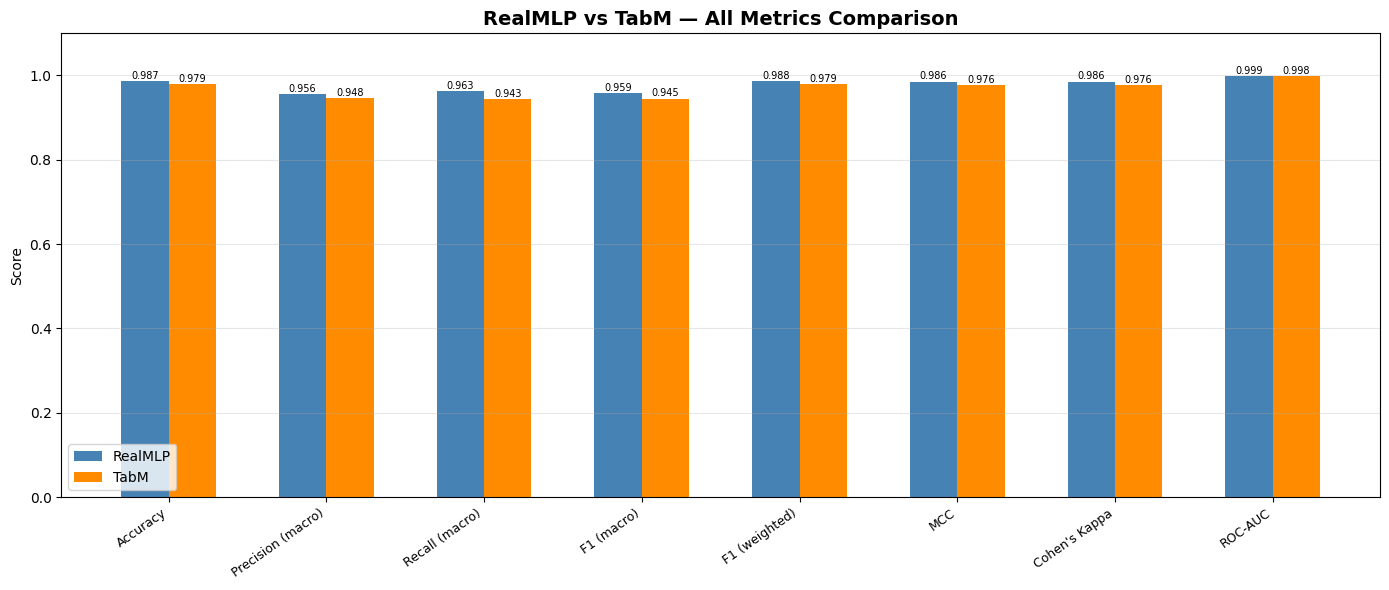


All results saved to /content/drive/MyDrive/toniot_outputs


In [18]:
# FINAL COMPARISON: RealMLP vs TabM


for name, m, tr_acc, tr_f1 in [
    ("RealMLP", realmlp_metrics, realmlp_train_acc, realmlp_train_f1),
    ("TabM",    tabm_metrics,    tabm_train_acc,    tabm_train_f1),
]:
    row = pd.DataFrame([{
        "model"           : name,
        "paper"           : "NeurIPS 2024 — Holzmüller et al." if name == "RealMLP"
                            else "ICLR 2025 — Gorishniy et al.",
        "dataset"         : "TON-IoT Network",
        "train_samples"   : len(X_train),
        "test_samples"    : len(X_test),
        "n_features"      : n_features,
        "n_classes"       : num_classes,
        "accuracy"        : m["acc"],
        "f1_macro"        : m["f1_macro"],
        "f1_weighted"     : m["f1_weighted"],
        "precision_macro" : m["prec_macro"],
        "recall_macro"    : m["rec_macro"],
        "mcc"             : m["mcc"],
        "cohen_kappa"     : m["kappa"],
        "roc_auc_macro"   : m["roc_auc"],
        "train_acc"       : tr_acc,
        "train_f1"        : tr_f1,
    }])
    csv_path = os.path.join(DRIVE_OUT_DIR, f"{name.lower()}_toniot_results.csv")
    row.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")

# Comparison table
comp_data = []
for name, m in [("RealMLP", realmlp_metrics), ("TabM", tabm_metrics)]:
    comp_data.append({
        "Model": name, "Accuracy": m["acc"], "Precision (macro)": m["prec_macro"],
        "Recall (macro)": m["rec_macro"], "F1 (macro)": m["f1_macro"],
        "F1 (weighted)": m["f1_weighted"], "MCC": m["mcc"],
        "Cohen's Kappa": m["kappa"], "ROC-AUC": m["roc_auc"]
    })

comp_df = pd.DataFrame(comp_data).set_index("Model")
print("\n========== FULL COMPARISON ==========")
print(comp_df.round(4).to_string())

# Comparison bar chart
fig, ax = plt.subplots(figsize=(14, 6))
metrics_list = list(comp_df.columns)
x = np.arange(len(metrics_list))
width = 0.3
r_vals = [comp_df.loc["RealMLP", m] for m in metrics_list]
t_vals = [comp_df.loc["TabM", m] for m in metrics_list]
r_vals = [v if v is not None else 0 for v in r_vals]
t_vals = [v if v is not None else 0 for v in t_vals]

bars1 = ax.bar(x - width/2, r_vals, width, label="RealMLP", color="steelblue")
bars2 = ax.bar(x + width/2, t_vals, width, label="TabM",    color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1.1); ax.set_ylabel("Score")
ax.set_title("RealMLP vs TabM — All Metrics Comparison", fontsize=14, fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.3f}", ha="center", fontsize=7)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.3f}", ha="center", fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUT_DIR, "toniot_realmlp_tabm_all_metrics.png"), dpi=150)
plt.show()
print(f"\nAll results saved to {DRIVE_OUT_DIR}")